<a href="https://colab.research.google.com/github/NatSy77/mlops_ai-projet6et8/blob/main/05_lightgbm_tuning_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initiez-vous au MLOps (partie 1/2)
LightGBM tuning

Objectif :
- réaliser une optimisation légère des hyperparamètres avec `RandomizedSearchCV`
- évaluer le modèle tuné sur le jeu de validation
- logger le meilleur run dans MLflow
- comparer ce modèle aux versions précédentes

> Ce notebook reste centré sur le **tuning**.  
> Le **réentraînement final sur tout le dataset** et l’**export pour l’API** seront faits dans un notebook séparé.

## Imports et configuration

In [1]:
!pip install -q mlflow lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 4.9 MB/s eta 0:00:00


In [2]:
import json
import re

import mlflow
import mlflow.lightgbm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split

RANDOM_STATE = 42

MLFLOW_TRACKING_URI = "file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"
EXPERIMENT_NAME = "credit_scoring_lightgbm"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.end_run()

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    mlflow.create_experiment(EXPERIMENT_NAME)

mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", mlflow.get_experiment_by_name(EXPERIMENT_NAME))

Tracking URI: file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns
Experiment: <Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/699024643397931554'), creation_time=1775456899065, experiment_id='699024643397931554', last_update_time=1775456899065, lifecycle_stage='active', name='credit_scoring_lightgbm', tags={}, workspace='default'>


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## Chargement des données

In [4]:
import os
from google.colab import drive

# Unmount Google Drive if already mounted to avoid conflicts
if os.path.exists('/content/drive'):
  print('Unmounting existing /content/drive...')
  try:
    drive.flush_and_unmount()
  except Exception as e:
    print(f'Error during unmount: {e}')

# Ensure the mount point is empty or doesn't exist
if os.path.exists('/content/drive'):
    if os.listdir('/content/drive'):
        print("Mount point '/content/drive' is not empty. Removing contents...")
        !rm -rf /content/drive/*

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Unmounting existing /content/drive...
Drive not mounted, so nothing to flush and unmount.
Mount point '/content/drive' is not empty. Removing contents...
Mounted at /content/drive


In [5]:
X = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/X_train.csv")
y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/y_train.csv").values.ravel()

print(X.shape, y.shape)
print("Taux classe positive :", y.mean())

(307511, 377) (307511,)
Taux classe positive : 0.08072881945686496


## Encodage et nettoyage des noms de colonnes

In [6]:
X_encoded = pd.get_dummies(X, drop_first=False)

def clean_feature_names(columns):
    cleaned = []
    seen = {}

    for col in columns:
        new_col = str(col)
        new_col = re.sub(r"[^A-Za-z0-9_]+", "_", new_col)
        new_col = re.sub(r"_+", "_", new_col)
        new_col = new_col.strip("_")

        if new_col == "":
            new_col = "feature"

        if new_col in seen:
            seen[new_col] += 1
            new_col = f"{new_col}_{seen[new_col]}"
        else:
            seen[new_col] = 0

        cleaned.append(new_col)

    return cleaned

X_encoded.columns = clean_feature_names(X_encoded.columns)

encoded_columns = X_encoded.columns.tolist()

with open("encoded_columns.json", "w") as f:
    json.dump(encoded_columns, f)

print("Shape après encodage :", X_encoded.shape)
print("Exemple colonnes :", encoded_columns[:10])

Shape après encodage : (307511, 501)
Exemple colonnes : ['SK_ID_CURR', 'PREV_PRODUCT_COMBINATION_CASH_MEAN', 'PREV_NAME_PORTFOLIO_CARS_MEAN', 'DAYS_LAST_PHONE_CHANGE', 'PREV_NAME_GOODS_CATEGORY_MOBILE_MEAN', 'PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN', 'BURO_BB_MONTHS_BALANCE_MAX_MEAN', 'PREV_CODE_REJECT_REASON_SYSTEM_MEAN', 'PREV_NAME_TYPE_SUITE_CHILDREN_MEAN', 'PREV_AMT_DOWN_PAYMENT_MEAN']


## Split train / validation

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)
y_val = pd.Series(y_val).reset_index(drop=True)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(246008, 501) (61503, 501)
(246008,) (61503,)


## Gestion du déséquilibre des classes

In [8]:
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight = n_negative / n_positive
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 11.38710976837865


## Fonctions métier et d'évaluation

In [9]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

def business_cost_normalized(y_true, y_pred, fn_cost=10, fp_cost=1):
    return business_cost(y_true, y_pred, fn_cost, fp_cost) / len(y_true)

def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    cost = business_cost_normalized(y_true, y_pred)

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "business_cost": cost
    }

def find_best_threshold(y_true, y_proba, fn_cost=10, fp_cost=1):
    thresholds = np.arange(0.01, 0.99, 0.01)
    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cost = business_cost_normalized(y_true, y_pred, fn_cost, fp_cost)
        results.append((t, cost))

    df = pd.DataFrame(results, columns=["threshold", "cost"])
    best_row = df.loc[df["cost"].idxmin()]

    return float(best_row["threshold"]), df

## Sous-échantillon pour le tuning

Le tuning est volontairement réalisé sur un sous-échantillon de 50 000 lignes pour limiter le temps de calcul,
tout en conservant un échantillon représentatif du dataset.

In [10]:
X_sample = X_train.sample(50000, random_state=RANDOM_STATE)
y_sample = y_train.loc[X_sample.index]

print(X_sample.shape, y_sample.shape)

(50000, 501) (50000,)


## RandomizedSearchCV léger
- num_leaves=15 : modèle plutôt régularisé, moins complexe
- min_child_samples=20 : un peu moins strict que le précédent essai à 40
- n_estimators=200 et learning_rate=0.05 : config simple, stable, raisonnable
- subsample=1.0 et colsample_bytree=1.0 : sur ce sous-échantillon, LightGBM préfère utiliser toute l’info

C’est cohérent, mais le score CV seul ne suffit pas pour choisir le modèle final.

La vraie décision se fait sur :

le coût métier,
le recall,
la PR AUC,
puis le ROC AUC

In [11]:
param_dist = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [20, 40],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        force_col_wise=True
    ),
    param_distributions=param_dist,
    n_iter=5,
    scoring="roc_auc",
    cv=2,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1
)

search.fit(X_sample, y_sample)

best_params = search.best_params_
print("Best params:", best_params)
print("Best CV ROC AUC:", search.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[LightGBM] [Info] Number of positive: 2015, number of negative: 22985
[LightGBM] [Info] Total Bins 39535
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 477
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080600 -> initscore=-2.434223
[LightGBM] [Info] Start training from score -2.434223
[CV] END colsample_bytree=1.0, learning_rate=0.05, min_child_samples=20, n_estimators=300, num_leaves=31, subsample=0.8; total time=  15.1s
[LightGBM] [Info] Number of positive: 2014, number of negative: 22986
[LightGBM] [Info] Total Bins 39420
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 474
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080560 -> initscore=-2.434763
[LightGBM] [Info] Start training from score -2.434763
[CV] END colsample_bytree=1.0, learning_rate=0.05, min_child_samples=20, n_estimators=300, num_leaves=31, subsample=0.8; total time=  

## Réentraînement du meilleur modèle tuné sur le train complet

In [12]:
tuned_model = LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    force_col_wise=True,
    **best_params
)

tuned_model.fit(X_train, y_train)

y_proba_tuned = tuned_model.predict_proba(X_val)[:, 1]
best_threshold_tuned, threshold_df_tuned = find_best_threshold(y_val, y_proba_tuned)
metrics_tuned = evaluate_model(y_val, y_proba_tuned, threshold=best_threshold_tuned)

print("Best threshold tuned:", best_threshold_tuned)
print(metrics_tuned)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 46916
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 490
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Best threshold tuned: 0.52
{'roc_auc': np.float64(0.7794599196034844), 'pr_auc': np.float64(0.2774137135516463), 'precision': 0.18624188533086028, 'recall': 0.6876132930513595, 'f1': 0.2930975274725275, 'business_cost': np.float64(0.4947238346096938)}


## Logging MLflow du modèle tuné

In [14]:
import mlflow

MLFLOW_TRACKING_URI = "file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"
EXPERIMENT_NAME = "credit_scoring_lightgbm_tuning"

# Reconnexion propre
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Fermer un éventuel run resté ouvert
mlflow.end_run()

# Recréer ou récupérer l'expérience par son nom
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    print("Nouvelle expérience créée :", experiment_id)
else:
    experiment_id = exp.experiment_id
    print("Expérience existante :", experiment_id)

mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Expérience active:", mlflow.get_experiment_by_name(EXPERIMENT_NAME))

Nouvelle expérience créée : 562923313514317022
Tracking URI: file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns
Expérience active: <Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/562923313514317022'), creation_time=1775457794605, experiment_id='562923313514317022', last_update_time=1775457794605, lifecycle_stage='active', name='credit_scoring_lightgbm_tuning', tags={}, workspace='default'>


In [15]:
with mlflow.start_run(run_name="lightgbm_random_search_best"):
    mlflow.set_tag("project", "home_credit_scoring")
    mlflow.set_tag("stage", "tuning")
    mlflow.set_tag("model_type", "lightgbm")
    mlflow.set_tag("run_role", "hyperparameter_search")
    mlflow.set_tag("dataset_version", "final_dataset_v1")
    mlflow.set_tag("author", "nathalie")

    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", float(scale_pos_weight))
    mlflow.log_param("fn_cost", 10)
    mlflow.log_param("fp_cost", 1)
    mlflow.log_param("threshold", float(best_threshold_tuned))

    mlflow.log_metric("cv_best_roc_auc", float(search.best_score_))
    for key, value in metrics_tuned.items():
        mlflow.log_metric(key, float(value))

    mlflow.log_artifact("encoded_columns.json")
    mlflow.lightgbm.log_model(tuned_model, name="model")

2026/04/06 06:43:20 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Graphiques d'analyse

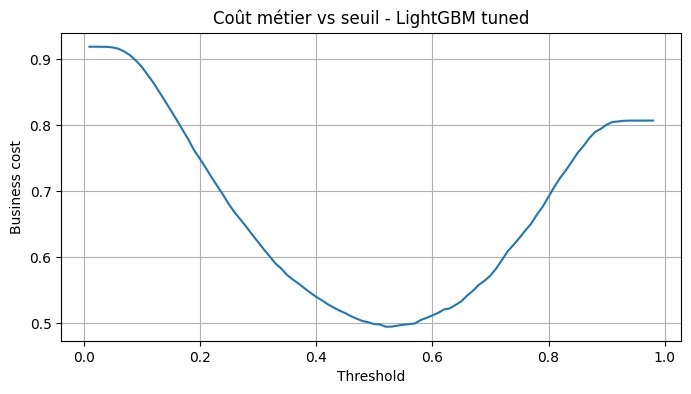

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df_tuned["threshold"], threshold_df_tuned["cost"])
plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.title("Coût métier vs seuil - LightGBM tuned")
plt.grid(True)
plt.show()

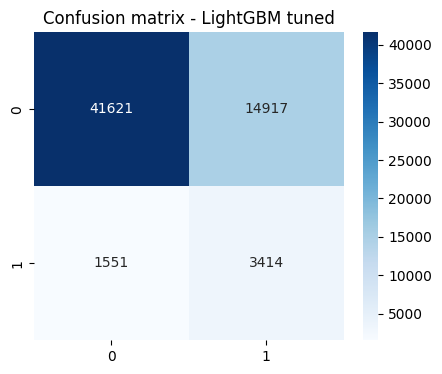

In [17]:
y_pred_tuned = (y_proba_tuned >= best_threshold_tuned).astype(int)
cm_tuned = confusion_matrix(y_val, y_pred_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix - LightGBM tuned")
plt.show()

In [18]:
feature_importances_tuned = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tuned_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances_tuned.head(20)

,feature,importance
246,EXT_SOURCE_1,156
172,EXT_SOURCE_2,130
72,EXT_SOURCE_3,110
251,PREV_CNT_PAYMENT_MEAN,101
113,AMT_CREDIT,94
33,DAYS_BIRTH,88
140,DAYS_EMPLOYED,74
242,INSTAL_AMT_PAYMENT_SUM,71
19,AMT_ANNUITY,67
93,INSTAL_DPD_MEAN,58


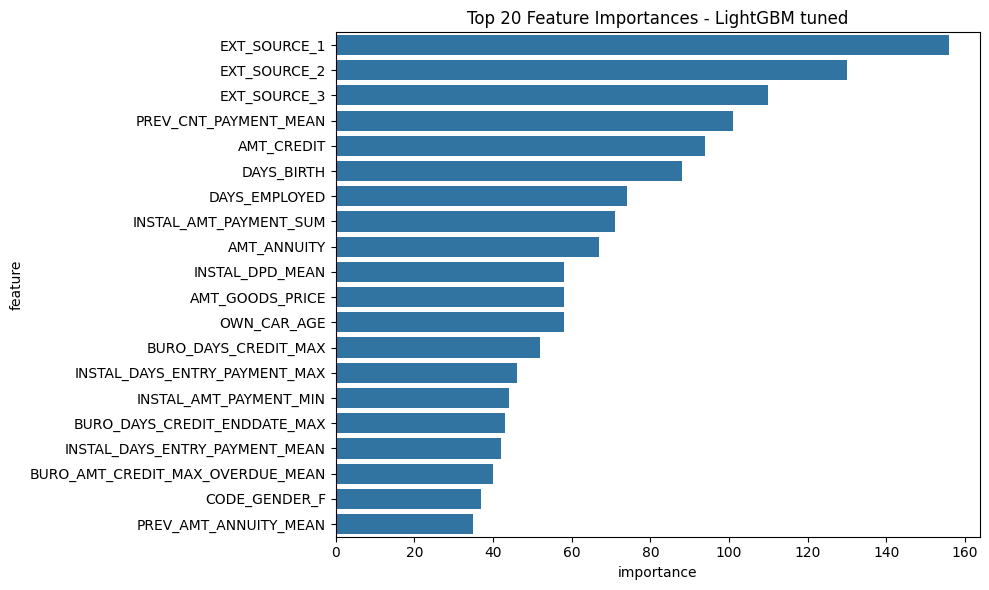

In [19]:
top_features_tuned = feature_importances_tuned.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features_tuned, x="importance", y="feature")
plt.title("Top 20 Feature Importances - LightGBM tuned")
plt.tight_layout()
plt.show()

## Tableau comparatif

In [20]:
comparison = pd.DataFrame([
    {
        "model": "logistic_regression",
        "roc_auc": 0.7684,
        "pr_auc": 0.2485,
        "precision": 0.1768,
        "recall": 0.6886,
        "f1": 0.2813,
        "business_cost": 0.5103,
        "threshold": 0.51
    },
    {
        "model": "lightgbm_early_stopping",
        "roc_auc": 0.6980,
        "pr_auc": 0.2038,
        "precision": 0.1792,
        "recall": 0.4359,
        "f1": 0.2540,
        "business_cost": 0.6165,
        "threshold": 0.11
    },
    {
        "model": "lightgbm_no_early_stopping",
        "roc_auc": 0.7825,
        "pr_auc": 0.2822,
        "precision": 0.1916,
        "recall": 0.6761,
        "f1": 0.2986,
        "business_cost": 0.4918,
        "threshold": 0.52
    },
    {
        "model": "lightgbm_tuned",
        "roc_auc": metrics_tuned["roc_auc"],
        "pr_auc": metrics_tuned["pr_auc"],
        "precision": metrics_tuned["precision"],
        "recall": metrics_tuned["recall"],
        "f1": metrics_tuned["f1"],
        "business_cost": metrics_tuned["business_cost"],
        "threshold": best_threshold_tuned
    }
])

comparison

,model,roc_auc,pr_auc,precision,recall,f1,business_cost,threshold
0,logistic_regression,0.76840,0.248500,0.176800,0.688600,0.281300,0.510300,0.51
1,lightgbm_early_stopping,0.69800,0.203800,0.179200,0.435900,0.254000,0.616500,0.11
2,lightgbm_no_early_stopping,0.78250,0.282200,0.191600,0.676100,0.298600,0.491800,0.52
3,lightgbm_tuned,0.77946,0.277414,0.186242,0.687613,0.293098,0.494724,0.52


## Conclusion

- une optimisation légère des hyperparamètres a bien été réalisée avec `RandomizedSearchCV`
- le modèle tuné est évalué sur le jeu de validation avec les mêmes métriques que les autres versions
- le choix du modèle final sera fait dans le notebook suivant, avant réentraînement sur tout le dataset et export pour l'API

Décision finale

Modèle retenu : lightgbm_no_early_stopping

Critère métier en priorité)
- Modèle	Business cost
- LogReg	0.5103
- LGBM early stop	0.6165
- LGBM simple	0.4918 (MEILLEUR)
- LGBM tuned	0.4947

Le coût métier le plus faible = meilleur modèle

Sur les autres métriques :
- PR AUC : 0.2822 (meilleure)
- ROC AUC : 0.7825 (meilleure)
- Recall : 0.6761 (très proche du tuned, OK)
- F1 : meilleur
Le tuned est bon… mais il ne bat pas le simple.

**Conclusion**

Le modèle LightGBM sans early stopping présente les meilleures performances globales, notamment en termes de coût métier, de PR AUC et de ROC AUC. Bien que le modèle optimisé par recherche d’hyperparamètres soit performant, il n’apporte pas d’amélioration significative sur le coût métier. Le modèle LightGBM simple est donc retenu comme modèle final.